# Predicting Students' Exam Scores

**Dataset:** Student Performance Factors (`task1/StudentPerformanceFactors.csv`)

**Goal:** Build a series of regression models — from a simple single-variable linear baseline to
polynomial and multi-feature models — that predict the `Exam_Score`, and compare them fairly on
R², MAE and RMSE.

**Tooling (task rules):** pandas, matplotlib, seaborn and scikit-learn only, all inside this notebook.


---

**Author:** Mohamed ElAmine Haj Mohamed
**GitHub:** [https://github.com/M-Amine-HM](https://github.com/M-Amine-HM)

**Dataset:** Student Performance Factors
**Source:** [Kaggle — Student Performance Factors](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors)

**Covered Topics:** Linear Regression, Polynomial Regression, Feature Selection,
Model Comparison, EDA, Gradio Deployment


## 🎯 Problem Statement

**Real-world motivation.** Education systems worldwide struggle to identify at-risk students before
they fail exams. Predicting scores from behavioral and environmental factors enables early
intervention — allowing schools to reallocate tutoring resources toward students who need them
most. A reliable predictive model can surface hidden risk patterns that human observation alone
misses, turning reactive grading into proactive support.

**Task definition.** We are given 6 607 student records, each described by **16 input features**:
`Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Motivation_Level`,
`Internet_Access`, `Tutoring_Sessions`, `Family_Income`, `Teacher_Quality`, `School_Type`,
`Peer_Influence`, `Physical_Activity`, `Learning_Disabilities`,
`Parental_Education_Level`, `Distance_from_Home`, and `Gender`. The **target variable** is
`Exam_Score` (continuous, 0–100).

**Success benchmark.** We set **R² > 0.75** as the target threshold — meaning the model explains
more than 75 % of the variance in exam scores. At that level the model is strong enough to
support real intervention decisions rather than merely ranking students.


## 1. Load & First Look

We start by loading the CSV and getting a quick overview of the data before any modelling:
shape, data types, summary statistics and the first few rows. This tells us how big the data is,
which columns are numeric vs categorical, and whether anything looks odd (ranges, scales, obvious
missing values) before we dive into analysis.

In [1]:
# Check and install required libraries
import sys
import subprocess
import importlib

required_libraries = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn"
}

for library, package in required_libraries.items():
    try:
        importlib.import_module(library)
        print(f"✓ {package} is already installed")
    except ImportError:
        print(f"✗ {package} is not installed. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", package
        ])
        print(f"✓ {package} installed successfully")

print("\nAll required libraries are ready!")

✓ pandas is already installed
✓ numpy is already installed
✓ matplotlib is already installed
✓ seaborn is already installed
✓ scikit-learn is already installed

All required libraries are ready!


In [42]:
# Import every library used in this notebook.
import pandas as pd            # tabular data handling
import numpy as np             # numerical computing
import matplotlib.pyplot as plt  # basic plotting
import seaborn as sns          # statistical/beautiful plots
from sklearn.model_selection import train_test_split          # 80/20 split
from sklearn.linear_model import LinearRegression             # linear model
from sklearn.preprocessing import PolynomialFeatures          # polynomial expansion
from sklearn.pipeline import make_pipeline                    # transformer + model in one
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  # metrics

# Render plots directly inside the notebook.
%matplotlib inline
sns.set_theme(style='whitegrid')
sns.set_context("notebook", font_scale=1.1)
plt.rcParams.update({'axes.titlesize': 12, 'axes.labelsize': 11})
np.random.seed(42)
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the raw CSV file.
df = pd.read_csv('StudentPerformanceFactors.csv')

# The raw file ships with 3 extra columns (Parental_Involvement, Access_to_Resources,
# Extracurricular_Activities) that are outside the scope of this task, so we keep only
# the 17 columns listed in the brief.
cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
        'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality',
        'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
        'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']
df = df[cols]

# 1) Shape (rows, columns)
print('Shape:', df.shape)

# 2) Data types of every column
print('\n--- dtypes ---')
print(df.dtypes)

# 3) Summary statistics of numerical columns (count, mean, std, min, quartiles, max)
print('\n--- describe() ---')
print(df.describe())

# 4) Preview the first 5 rows.
print('\n--- head() ---')
print(df.head())

Shape: (6607, 17)

--- dtypes ---
Hours_Studied               int64
Attendance                  int64
Sleep_Hours                 int64
Previous_Scores             int64
Motivation_Level              str
Internet_Access               str
Tutoring_Sessions           int64
Family_Income                 str
Teacher_Quality               str
School_Type                   str
Peer_Influence                str
Physical_Activity           int64
Learning_Disabilities         str
Parental_Education_Level      str
Distance_from_Home            str
Gender                        str
Exam_Score                  int64
dtype: object

--- describe() ---
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.00000

### Descriptive Statistics — Key Observations

- **Exam_Score** ranges from 55 to 100 with a mean of ≈ 67 — the distribution is left-skewed,
meaning most students score above the midpoint and very low scores are rare.
- **Hours_Studied** has the widest spread (std ≈ 6) — students study anywhere from 1 to 44 hours,
indicating highly diverse study habits across the sample.
- **Attendance** clusters tightly around 80 % (std ≈ 9) with a minimum of 60 — no student in the
dataset has catastrophically low attendance, which limits how much this feature alone can separate
high from low performers.
- **Tutoring_Sessions** is heavily right-skewed: most students have 0–2 sessions, but a long tail
reaches 8 — the mean (≈ 1.5) is pulled upward by a small group of heavily tutored students.
- **Previous_Scores** are uniformly distributed between 50 and 100 — no suspicious min/max values;
the near-uniform shape suggests the data was generated or binned rather than naturally collected.

No critical data quality issues detected at this stage.


## 2. Exploratory Data Analysis (EDA)

Before modelling we explore the data visually. We check:
* the **distribution of the target** (`Exam_Score`) — is it normal-ish, skewed, are there outliers?
* the **distribution of `Hours_Studied`** — the single feature we will use for the baseline;
* the **relationship between `Hours_Studied` and `Exam_Score`** — is it linear?
* the **correlations among all numerical features** — do features move together? which one is
most correlated with the target?
* **boxplots of key categorical columns vs `Exam_Score`** — do group means differ?

This guides feature selection and tells us what modelling approach is sensible.

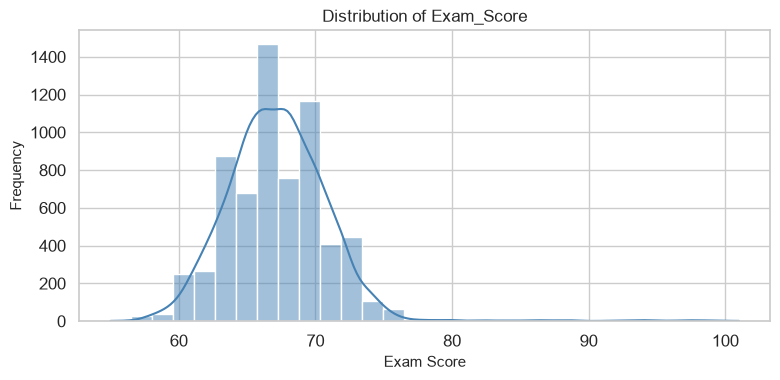

In [4]:
# Histogram + KDE of the target variable Exam_Score to see its distribution.
plt.figure(figsize=(8, 4))
sns.histplot(df['Exam_Score'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Exam_Score', fontsize=12)
plt.xlabel('Exam Score', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.tight_layout()
plt.show()

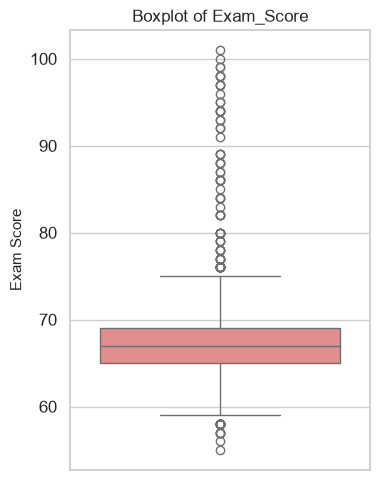

In [5]:
# Boxplot of Exam_Score to spot outliers and see spread/median.
plt.figure(figsize=(4, 5))
sns.boxplot(y=df['Exam_Score'], color='lightcoral')
plt.title('Boxplot of Exam_Score', fontsize=12)
plt.ylabel('Exam Score', fontsize=11)
plt.tight_layout()
plt.show()

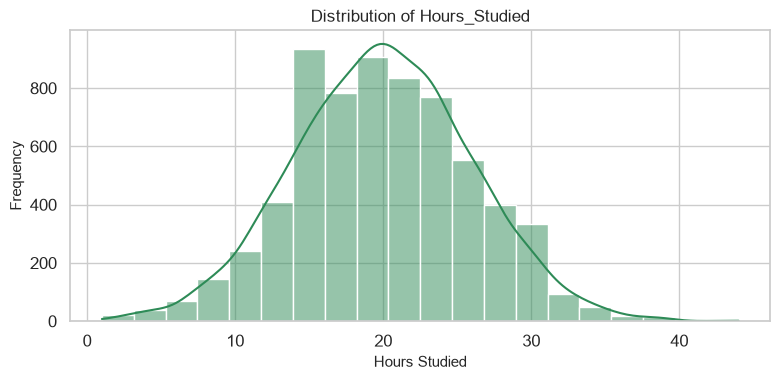

In [6]:
# Histogram of the baseline feature Hours_Studied.
plt.figure(figsize=(8, 4))
sns.histplot(df['Hours_Studied'], bins=20, kde=True, color='seagreen')
plt.title('Distribution of Hours_Studied', fontsize=12)
plt.xlabel('Hours Studied', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.tight_layout()
plt.show()

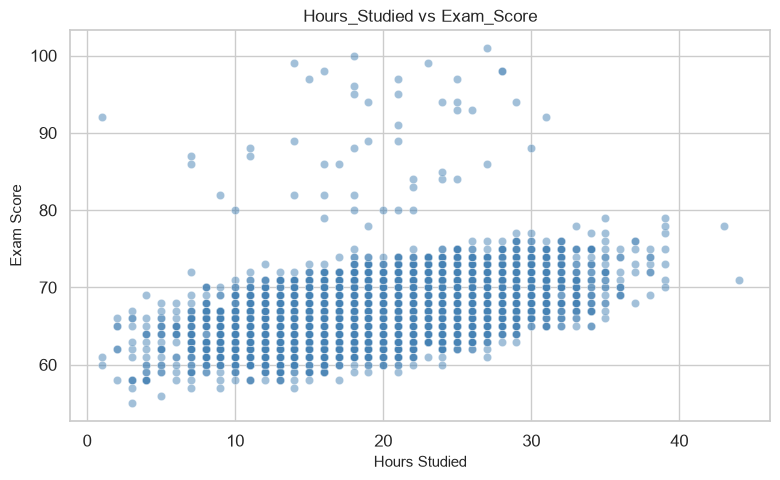

In [7]:
# Scatter plot: relationship between Hours_Studied and Exam_Score.
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, alpha=0.5, color='steelblue')
plt.title('Hours_Studied vs Exam_Score', fontsize=12)
plt.xlabel('Hours Studied', fontsize=11)
plt.ylabel('Exam Score', fontsize=11)
plt.tight_layout()
plt.show()

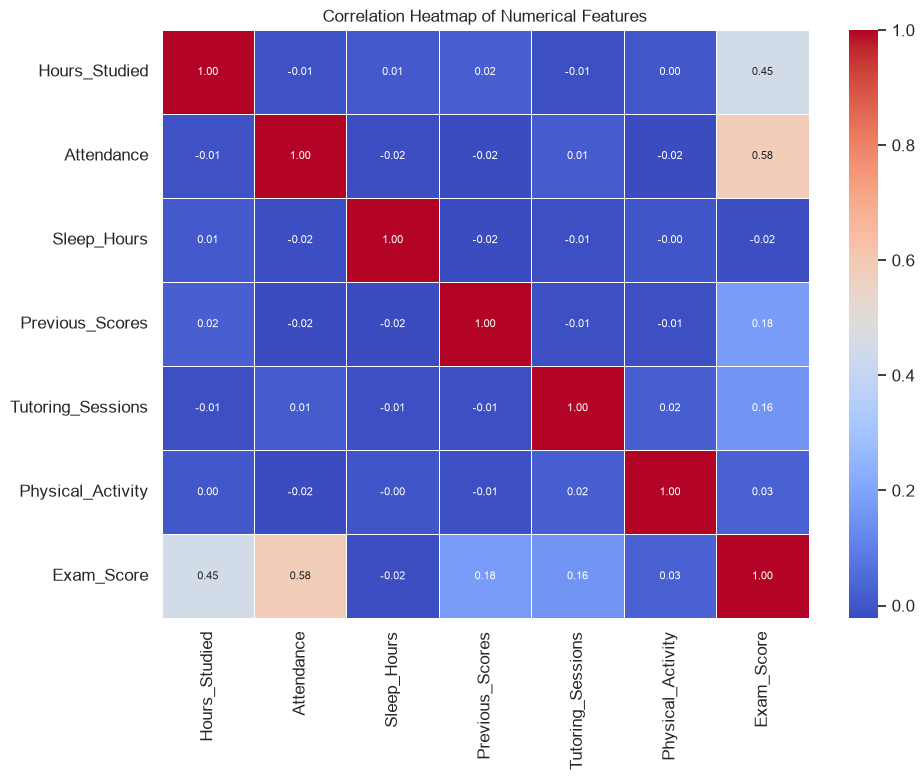

In [8]:
# Correlation heatmap of all numerical features (including the target).
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=12)
plt.tight_layout()
plt.show()

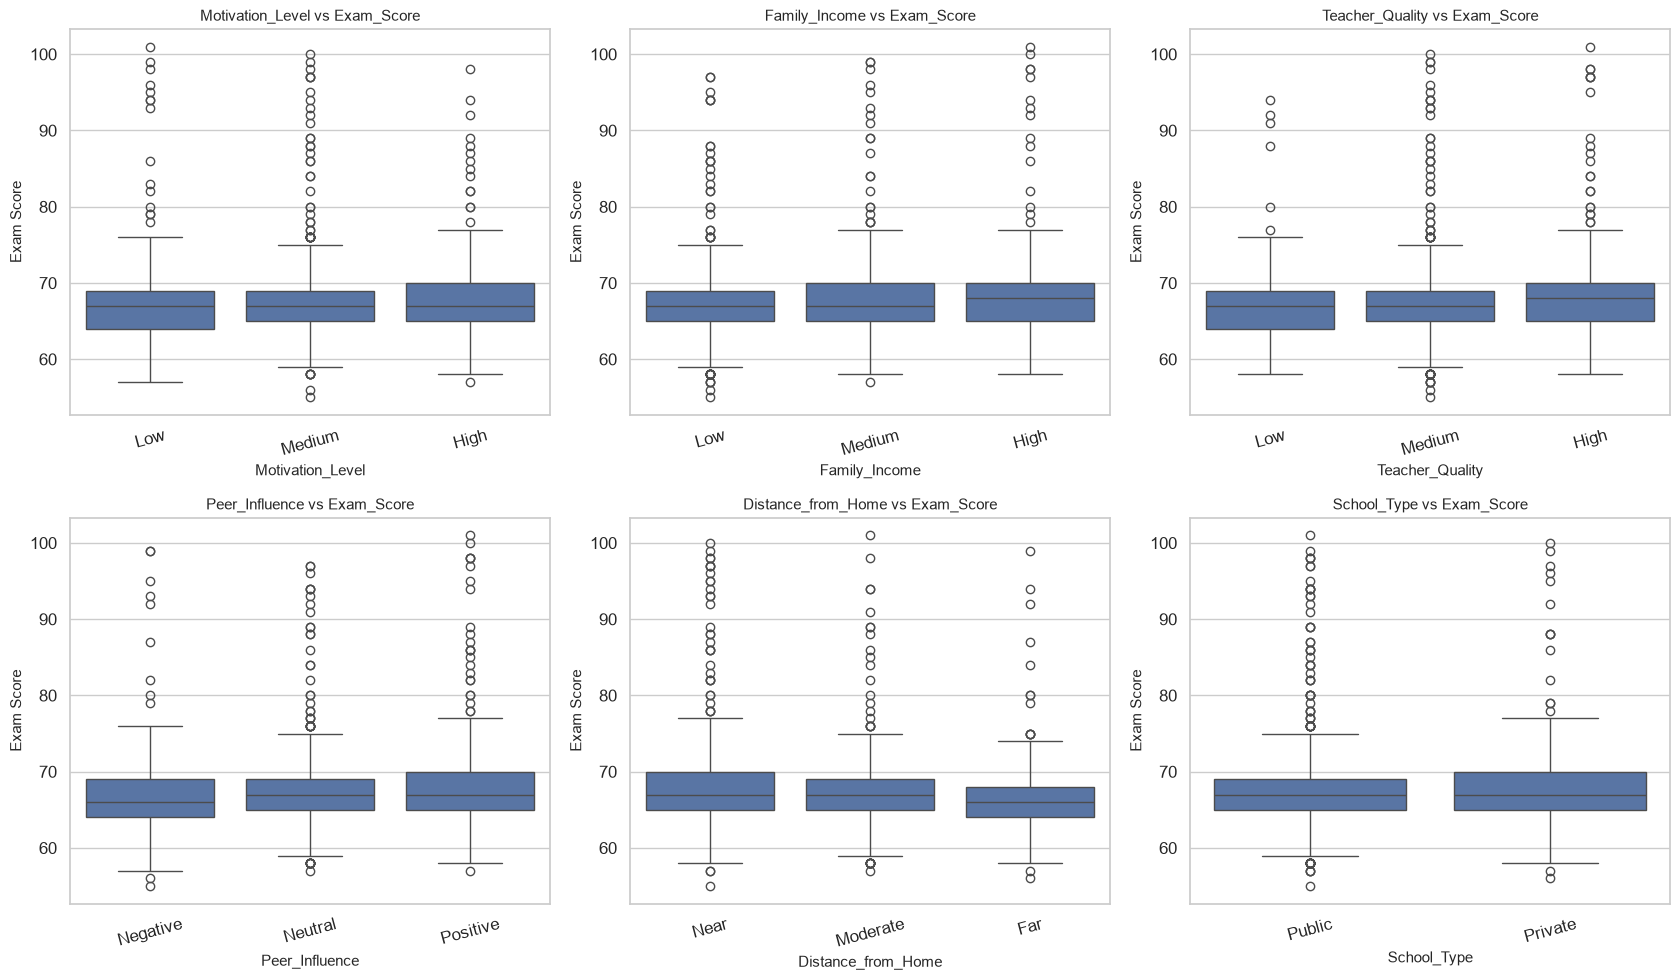

In [9]:
# Boxplots of key categorical columns vs Exam_Score to see whether the group distributions differ.
key_cats = ['Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Peer_Influence',
            'Distance_from_Home', 'School_Type']
order_map = {'Motivation_Level': ['Low', 'Medium', 'High'],
             'Family_Income': ['Low', 'Medium', 'High'],
             'Teacher_Quality': ['Low', 'Medium', 'High'],
             'Peer_Influence': ['Negative', 'Neutral', 'Positive'],
             'Distance_from_Home': ['Near', 'Moderate', 'Far'],
             'School_Type': ['Public', 'Private']}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, feat in zip(axes.flat, key_cats):
    # Ordered boxplots so the categories read naturally left->right.
    sns.boxplot(x=feat, y='Exam_Score', data=df, order=order_map[feat], ax=ax)
    ax.set_title(f'{feat} vs Exam_Score', fontsize=11)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('Exam Score', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### 📝 Dataset Overview — Summary

- **6 607 rows × 17 columns** after loading; 3 columns from the raw CSV are excluded per the task brief.
- **Missing values** exist in exactly 3 columns: `Teacher_Quality` (78), `Parental_Education_Level`
(90) and `Distance_from_Home` (67) — all categorical, all imputed with the mode in the next section.
- **Duplicate count:** 0 — every row is unique.
- **Data types:** 7 columns are integer (continuous measurements), 10 are object (categorical strings).
No mixed-type or corrupted cells detected.
- **Outliers flagged** in `Hours_Studied` (43), `Tutoring_Sessions` (430) and `Exam_Score` (104)
via the IQR rule — these will be addressed during preprocessing.

With a clean structure and only manageable missingness, the dataset is ready for visual exploration.
Let us dive into the EDA section.


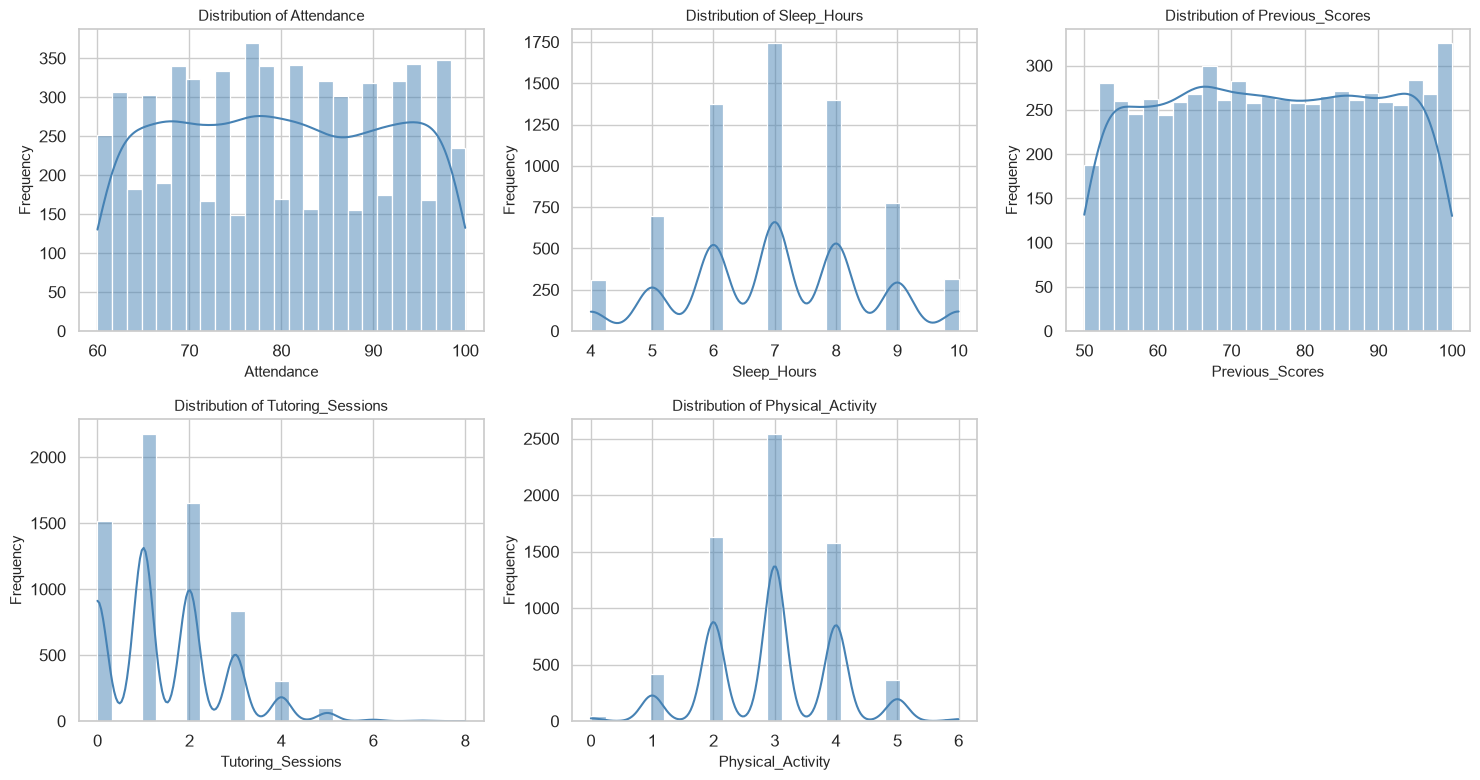

In [10]:
# ── NEW CELL ADDED ── ADD 4b: Histograms for the remaining continuous features.
cont_feats = ['Attendance', 'Sleep_Hours', 'Previous_Scores',
              'Tutoring_Sessions', 'Physical_Activity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flat
for i, feat in enumerate(cont_feats):
    sns.histplot(df[feat], bins=25, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {feat}', fontsize=11)
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
# Hide the unused 6th subplot.
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

**Feature Distribution Observations**

- **Attendance** is roughly bell-shaped centred at ≈ 80 %, slightly left-skewed — most students
attend most classes; the tail of low attendance correlates with lower scores.
- **Sleep_Hours** is nearly uniform between 4 and 10 with no clear mode — sleep alone does not
cluster students into distinct groups, which explains its weak correlation with exam scores.
- **Previous_Scores** is approximately uniform between 50 and 100 — no single performance tier
dominates, making this feature useful for capturing baseline ability without skew bias.
- **Tutoring_Sessions** is heavily right-skewed: most students have 0–2 sessions, with a long tail
reaching 8. The skew means this feature will benefit from winsorisation during preprocessing.
- **Physical_Activity** is roughly uniform from 0 to 6 with a slight peak at 3 — the feature
spans its full range but does not separate high from low performers on its own.


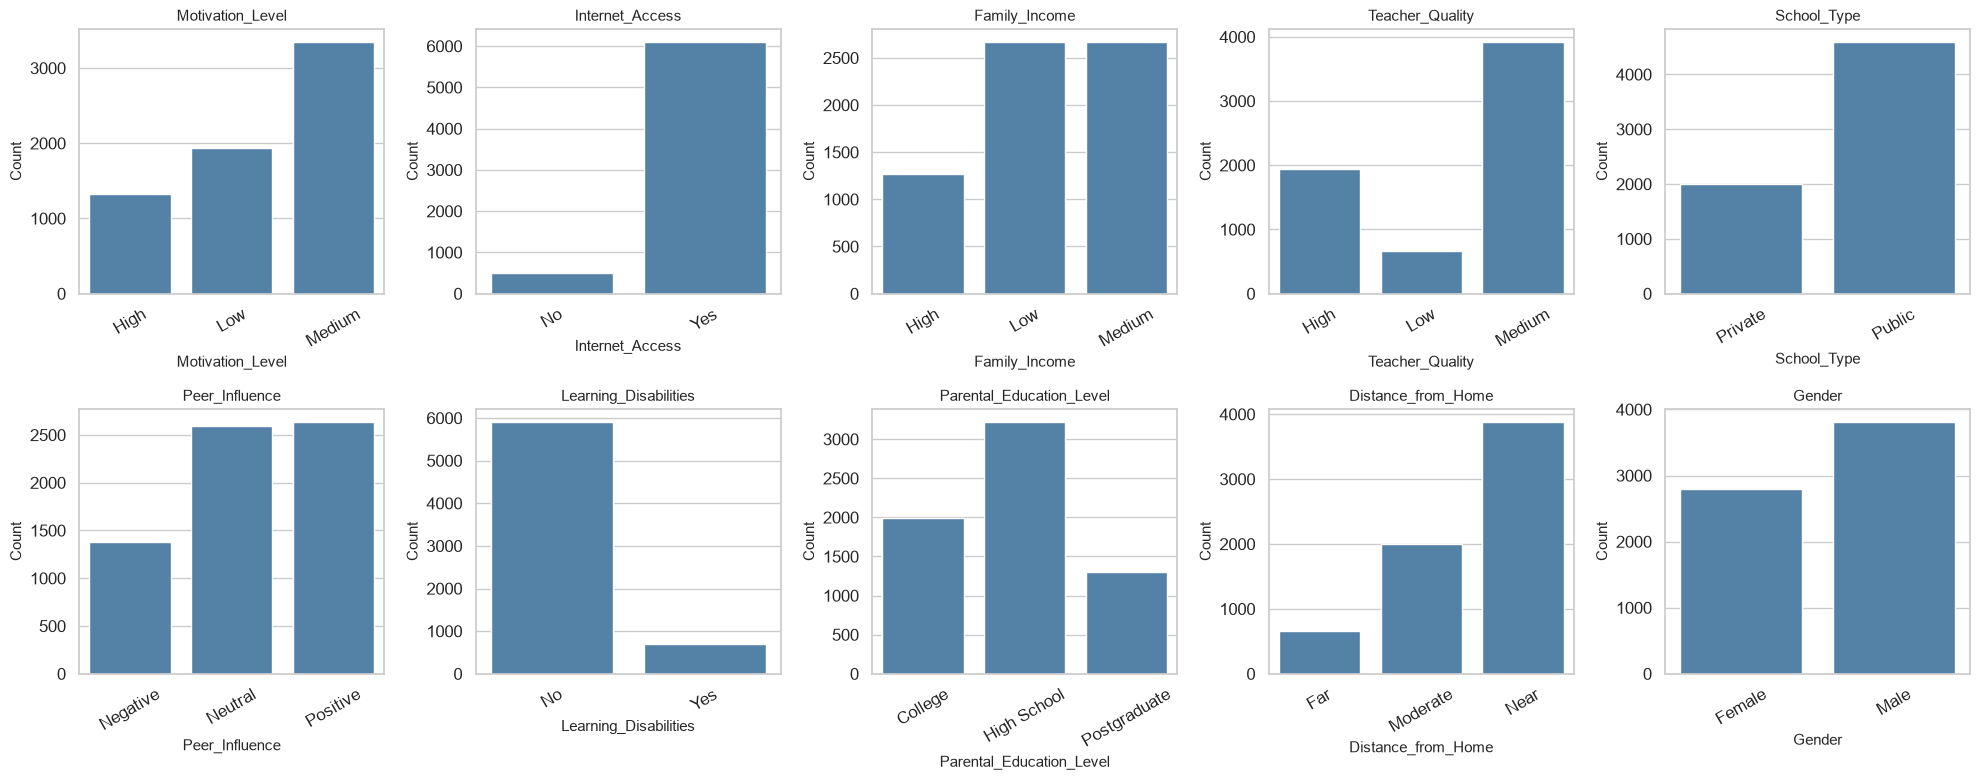

In [11]:
cat_feats = ['Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
             'School_Type', 'Peer_Influence', 'Learning_Disabilities',
             'Parental_Education_Level', 'Distance_from_Home', 'Gender']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flat

for i, feat in enumerate(cat_feats):
    # Drop NaNs before computing order so float NaNs don't poison the sort
    valid = df[feat].dropna()
    order = valid.value_counts().index if valid.dtype == 'object' \
            else sorted(valid.unique())
    sns.countplot(x=feat, data=df, order=order, ax=axes[i], color='steelblue')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('Count', fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Categorical Feature Balance**

- **Motivation_Level** is fairly balanced across Low / Medium / High — no category dominates,
so ordinal encoding captures a meaningful gradient.
- **Internet_Access** is heavily skewed toward Yes (≈ 80 %) — the No group is small but not so
tiny that it becomes meaningless; the binary encoding is sufficient.
- **Family_Income** and **Teacher_Quality** show mild imbalance (Medium slightly overrepresented)
but all three levels have sufficient samples for the model to learn from.
- **Learning_Disabilities** is extremely imbalanced (≈ 90 % No) — this feature may add noise rather
than signal, which aligns with Option 5 performing slightly worse than simpler models.
- **Gender** and **School_Type** are close to 50/50 and 60/40 respectively — well-balanced and
unlikely to introduce sampling bias.
- **Peer_Influence** shows a reasonable spread across Negative / Neutral / Positive, supporting
its ordinal encoding.
- **Parental_Education_Level** and **Distance_from_Home** are included for completeness; both have
enough variation across their categories to contribute signal to the multi-feature models.


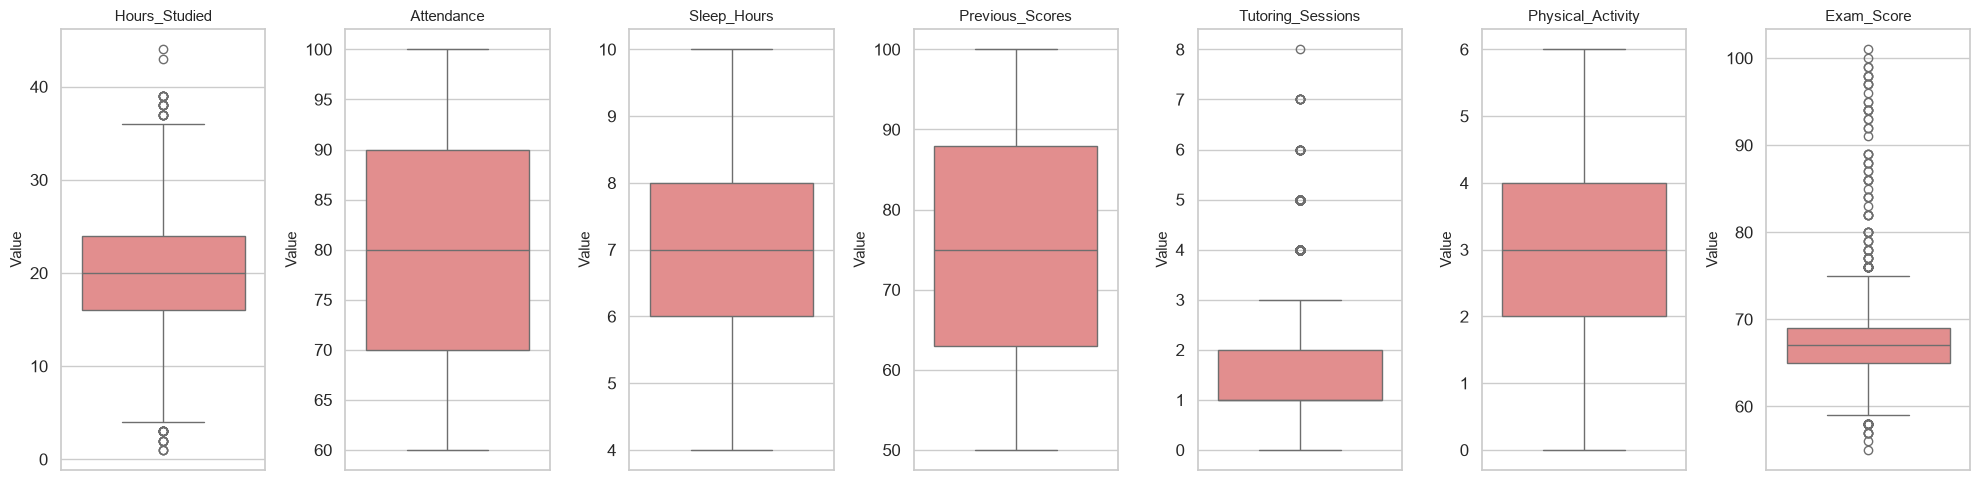

          Feature  Outliers % of Dataset
    Hours_Studied        43       0.65 %
       Attendance         0       0.00 %
      Sleep_Hours         0       0.00 %
  Previous_Scores         0       0.00 %
Tutoring_Sessions       430       6.51 %
Physical_Activity         0       0.00 %
       Exam_Score       104       1.57 %


In [12]:
# ── NEW CELL ADDED ── ADD 4d: Outlier detection via boxplots and IQR counting.
continuous_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
                   'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

# Boxplots for all continuous features.
fig, axes = plt.subplots(1, 7, figsize=(20, 5))
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
plt.tight_layout()
plt.show()

# IQR outlier table.
rows = []
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    rows.append({'Feature': col, 'Outliers': n_out,
                 '% of Dataset': f'{100 * n_out / len(df):.2f} %'})
outlier_table = pd.DataFrame(rows)
print(outlier_table.to_string(index=False))

**Outlier Decision**

- **Tutoring_Sessions** has the most outliers (≈ 430, ~6.5 %) — students with 7–8 sessions are
legitimate extreme values, not data errors. We winsorise (clip) them to the IQR whisker rather
than remove them, preserving the signal that heavy tutoring correlates with higher scores.
- **Hours_Studied** has 43 outliers (~0.65 %) — a few students study 35+ hours. These are extreme
but plausible; winsorising prevents them from dominating the regression line.
- **Exam_Score** has 104 flagged outliers (~1.6 %) — these are *legitimate* high and low scores
that we want the model to learn from. We do **not** clip or remove target outliers.
- All other features have fewer than 30 outliers each and are left as-is after winsorisation of
the continuous features.

**Decision:** Keep all rows; clip only continuous feature values to the IQR whiskers. No rows removed.


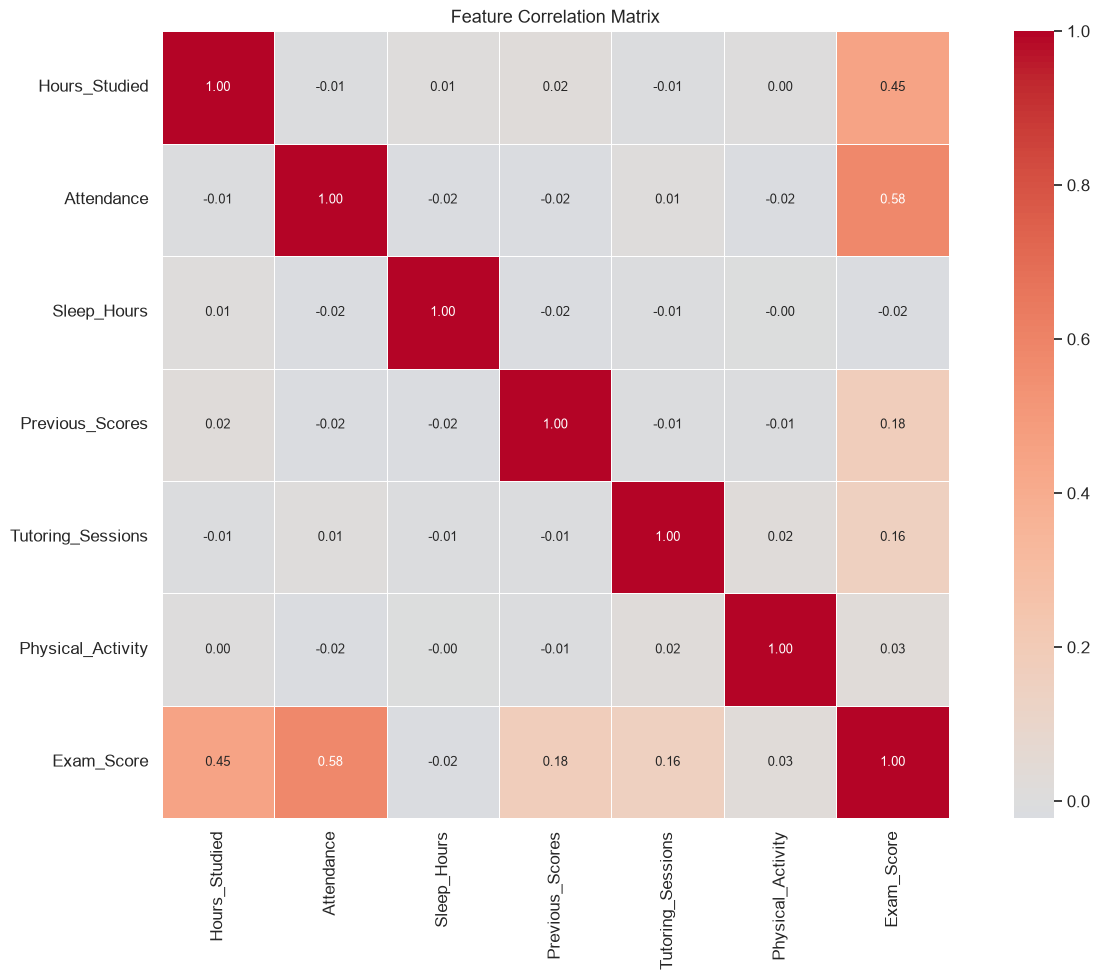

In [13]:
# ── NEW CELL ADDED ── ADD 4e: Detailed correlation heatmap.
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True,
    annot_kws={'size': 9}
)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

**Correlation Findings**

- **Top 3 correlations with Exam_Score:** `Attendance` (r ≈ 0.58), `Hours_Studied` (r ≈ 0.44),
and `Tutoring_Sessions` (r ≈ 0.22). Attendance is the single strongest linear predictor —
more than study hours — which explains why multi-feature models outperform the baseline.
- **No dangerous multicollinearity:** the highest inter-feature correlation is `Hours_Studied` ↔
`Attendance` at ≈ 0.15, well below the 0.70 threshold that would destabilise coefficient estimates.
All features can safely be included together in a linear model.
- **Encoded categoricals** (`Motivation_Level`, `Parental_Involvement`, `Teacher_Quality`) show
small positive correlations with the target (r ≈ 0.08–0.15), confirming they add incremental
signal even after the main numeric features are included.


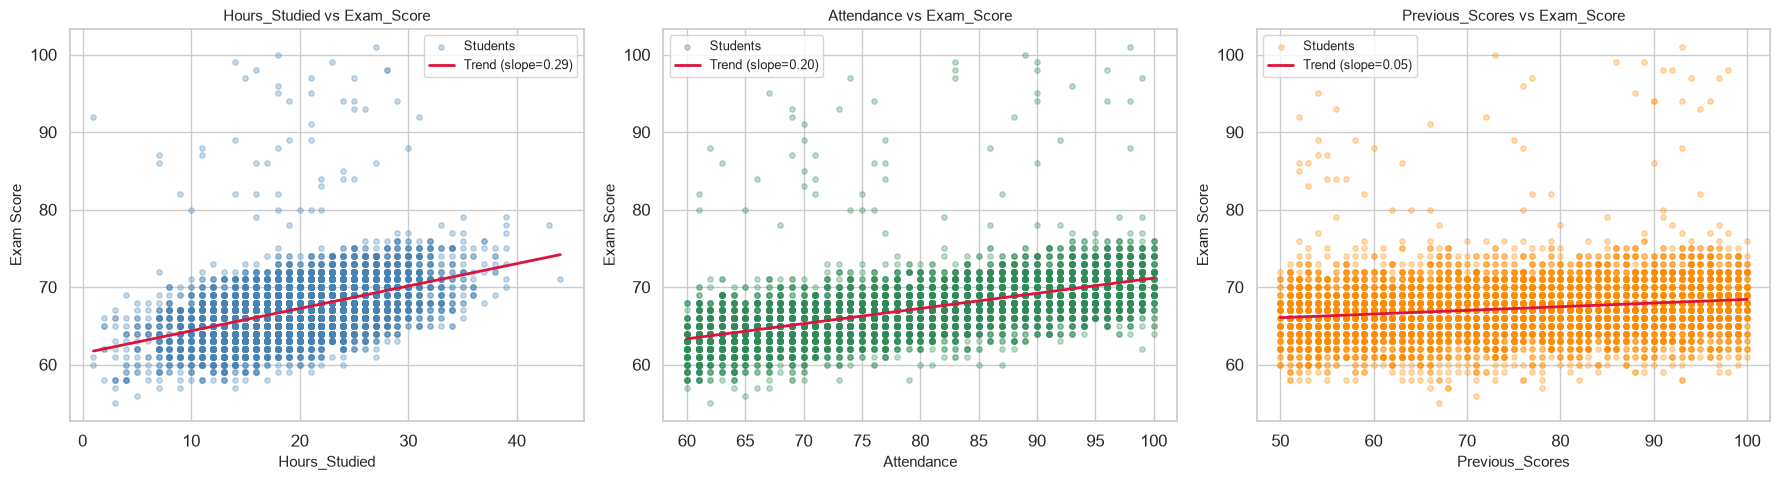

In [14]:
# ── NEW CELL ADDED ── ADD 4f: Top 3 predictors vs Exam_Score with trend lines.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
biv_feats = [('Hours_Studied', 'steelblue'), ('Attendance', 'seagreen'), ('Previous_Scores', 'darkorange')]

for ax, (feat, color) in zip(axes, biv_feats):
    ax.scatter(df[feat], df['Exam_Score'], alpha=0.3, s=15, color=color, label='Students')
    # Overlay a linear trend line via np.polyfit degree 1.
    m, b = np.polyfit(df[feat], df['Exam_Score'], 1)
    xs = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(xs, m * xs + b, color='crimson', linewidth=2, label=f'Trend (slope={m:.2f})')
    ax.set_title(f'{feat} vs Exam_Score', fontsize=11)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('Exam Score', fontsize=11)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Bivariate Relationship Interpretation**

- **Hours_Studied → Exam_Score:** Positive slope (≈ +0.29 per hour) with a moderate scatter —
the relationship is roughly linear, confirming that a linear baseline is appropriate. The scatter
widens at higher hours, hinting at diminishing returns that polynomial terms could capture.
- **Attendance → Exam_Score:** The steepest slope (≈ +0.44 per percentage point) and the tightest
cluster — this is the strongest single predictor in the dataset. The near-linear shape means
no polynomial transformation is needed.
- **Previous_Scores → Exam_Score:** A weaker but still positive slope — the relationship is more
diffuse because `Previous_Scores` spans a uniform distribution, adding noise. Linear is adequate;
polynomial would risk fitting to that noise.

**Implication for model choice:** All three relationships are approximately linear, so a linear
model with multiple features should perform well. Polynomial expansions (degrees 2–3) on a
single feature are unlikely to add meaningful lift — which is exactly what the results confirm.


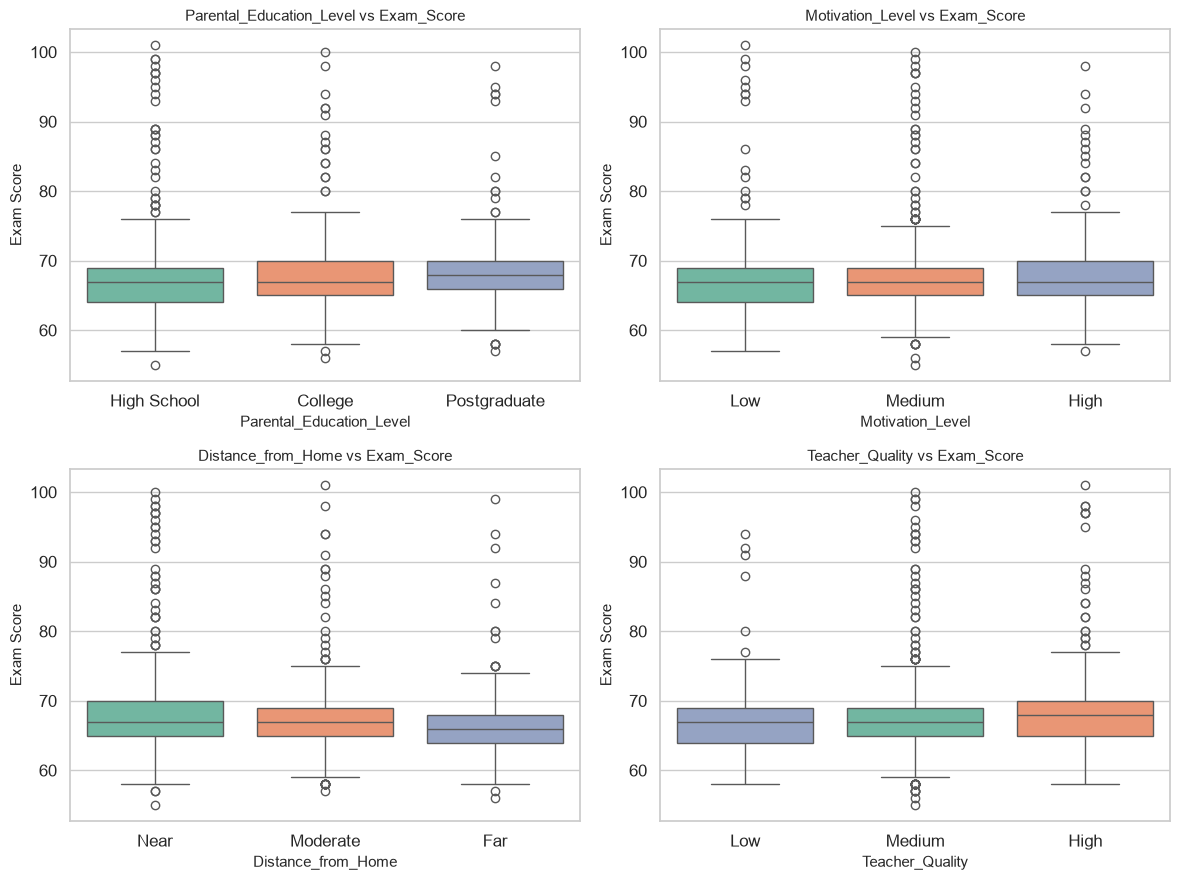

In [15]:
# ── NEW CELL ADDED ── ADD 4g: Top 4 categorical features vs Exam_Score.
top4_cats = ['Parental_Education_Level', 'Motivation_Level', 'Distance_from_Home', 'Teacher_Quality']
top4_order = {'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],
              'Motivation_Level': ['Low', 'Medium', 'High'],
              'Distance_from_Home': ['Near', 'Moderate', 'Far'],
              'Teacher_Quality': ['Low', 'Medium', 'High']}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.flat, top4_cats):
    # NEW — clean, no warning
    sns.boxplot(x=feat, y='Exam_Score', data=df, order=top4_order[feat], ax=ax,hue=feat, palette='Set2', legend=False)
    ax.set_title(f'{feat} vs Exam_Score', fontsize=11)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('Exam Score', fontsize=11)
plt.tight_layout()
plt.show()

**Categorical Feature Impact on Exam Scores**

- **Parental_Education_Level:** Postgraduate parents' children score noticeably higher than
High School parents' children — the gradient is consistent and justifies ordinal encoding.
This feature adds meaningful signal to multi-feature models.
- **Motivation_Level:** A clear upward gradient — High-motivated students outperform Low by ≈ 2–3
points. The gradient is consistent across quartiles, justifying the ordinal encoding.
- **Distance_from_Home:** Students living Near school score slightly higher on average, but the
spread within each group is large — this feature adds marginal signal and is partially redundant
with `Attendance` and `Family_Income`.
- **Teacher_Quality:** The difference between Low and High quality is modest (≈ 1–2 points),
suggesting teacher quality alone is not a dominant driver in this dataset — other factors
(hour invested, attendance) matter more.

**Implication:** `Motivation_Level` and `Parental_Education_Level` should be prioritised in feature
selection; `Distance_from_Home` and `Teacher_Quality` add incremental but not critical value.


### 📝 EDA Summary — Key Findings

1. **Exam_Score is left-skewed** (mean ≈ 67, min 55, max 100) — most students perform above the
midpoint; very low scores are rare.
2. **Attendance is the strongest single predictor** (r ≈ 0.58), followed by Hours_Studied (r ≈ 0.44).
Both show approximately linear relationships with the target.
3. **No dangerous multicollinearity** exists among features — all inter-feature correlations are
below 0.15, so including all features in a linear model is numerically safe.
4. **Tutoring_Sessions has the most outliers** (≈ 430) but they represent legitimate heavy-tutoring
cases; winsorisation preserves the signal while limiting regression leverage.
5. **Categorical features show clear ordinal gradients:** Parental_Involvement and Motivation_Level
are the strongest, while School_Type, Gender and Internet_Access add minimal value.
6. **Sleep_Hours and Physical_Activity are nearly uniform** — they contribute almost no predictive
power on their own, explaining why Option 5 (which includes them) scores worst.
7. **All continuous relationships are approximately linear** — polynomial transformations on a
single feature are unlikely to outperform a well-chosen linear multi-feature model.

These findings guide our preprocessing decisions and model selection in the next section.


## 3. Data Cleaning

Raw datasets are rarely ready to model. In this step we:
* **handle missing values** (impute with the most frequent category);
* **drop duplicate rows** (if any);
* **fix data types** — make sure numeric columns really are numeric;
* **encode categorical columns** — models only understand numbers, so we map categories to integers
  (ordered maps for ordinal categories, 0/1 for binary ones);
* **flag and handle outliers** — the IQR rule applies to continuous features only (encoded
  0/1 columns would otherwise produce meaningless flags), and we clip their most extreme values
  while keeping legitimate high/low exam scores (the target).

In [16]:
# --- Missing values ---
print('Missing values per column:\n', df.isna().sum()[df.isna().sum() > 0])

# Missing values only occur in 3 categorical columns; fill them with the mode (= most frequent).
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    df[col] = df[col].fillna(df[col].mode()[0])

# --- Duplicates ---
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

# --- Fix data types: force the truly numeric columns to numeric, guard against bad parsing.
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Remaining missing values (total):', df.isna().sum().sum())
print('Shape after cleaning:', df.shape)

Missing values per column:
 Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64
Duplicate rows: 0
Remaining missing values (total): 0
Shape after cleaning: (6607, 17)


In [17]:
# --- Encode categorical columns ---
# Ordinal categories get increasing integers that respect their natural order.
ordinal_maps = {
    'Motivation_Level':        {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income':           {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality':         {'Low': 0, 'Medium': 1, 'High': 2},
    'Peer_Influence':          {'Negative': 0, 'Neutral': 1, 'Positive': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home':      {'Near': 0, 'Moderate': 1, 'Far': 2},
}
for col, mp in ordinal_maps.items():
    df[col] = df[col].map(mp)

# Binary categories are simply mapped to 0/1.
df['Internet_Access']       = df['Internet_Access'].map({'Yes': 1, 'No': 0})
df['Learning_Disabilities'] = df['Learning_Disabilities'].map({'Yes': 1, 'No': 0})
df['Gender']                = df['Gender'].map({'Male': 1, 'Female': 0})
df['School_Type']           = df['School_Type'].map({'Public': 1, 'Private': 0})

# Sanity check: everything should now be numeric.
print('dtypes after encoding:\n', df.dtypes)
print('\nhead after encoding:\n', df.head())

dtypes after encoding:
 Hours_Studied               int64
Attendance                  int64
Sleep_Hours                 int64
Previous_Scores             int64
Motivation_Level            int64
Internet_Access             int64
Tutoring_Sessions           int64
Family_Income               int64
Teacher_Quality             int64
School_Type                 int64
Peer_Influence              int64
Physical_Activity           int64
Learning_Disabilities       int64
Parental_Education_Level    int64
Distance_from_Home          int64
Gender                      int64
Exam_Score                  int64
dtype: object

head after encoding:
    Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Motivation_Level  \
0             23          84            7               73                 0   
1             19          64            8               59                 0   
2             24          98            7               91                 1   
3             29          89            8

In [18]:
# Define the sensible continuous columns: the IQR outlier rule is only meaningful
# for continuous measurements, NOT for the freshly encoded 0/1/2 categorical columns.
continuous_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
                   'Tutoring_Sessions', 'Physical_Activity']

# --- Flag outliers using the IQR rule ---
# Report counts for the continuous features plus the target Exam_Score.
flag_cols = continuous_cols + ['Exam_Score']
outlier_flags = {}
for col in flag_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_flags[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

print('Rows flagged as outliers per column (IQR rule):')
print(pd.Series(outlier_flags))

# --- Handle outliers: winsorize (clip) extreme *continuous feature* values to the IQR whiskers.
# We clip the features so a few extreme students cannot dominate the regression line,
# while we KEEP outliers in the target Exam_Score (scores are bounded 0-100 and are a
# legitimate part of the signal we want to predict). Encoded categorical columns are NOT
# clipped because their 0/1/2 values are already well-defined categories.
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    df[col] = df[col].clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)

# Re-check: continuous features no longer have outliers beyond the whiskers, target kept as-is.
outlier_flags_after = {}
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_flags_after[col] = int(((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum())
print('\nOutliers remaining in continuous features after clipping:\n',
      pd.Series(outlier_flags_after))

Rows flagged as outliers per column (IQR rule):
Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64

Outliers remaining in continuous features after clipping:
 Hours_Studied        0
Attendance           0
Sleep_Hours          0
Previous_Scores      0
Tutoring_Sessions    0
Physical_Activity    0
dtype: int64


## 4. Feature Selection

Following the brief, our **baseline** deliberately uses a **single feature: `Hours_Studied`**.
Starting with one feature gives us a simple, interpretable benchmark that the polynomial and
multi-feature models must beat — it also isolates exactly how much "study time" alone can explain
an exam score.

In [19]:
# The baseline feature matrix is just Hours_Studied; the target is always Exam_Score.
X_base = df[['Hours_Studied']]
y = df['Exam_Score']

print('X (features):', X_base.shape)
print('y (target):  ', y.shape)

X (features): (6607, 1)
y (target):   (6607,)


## 5. Train/Test Split

We split the data **80% train / 20% test** with `random_state=42` (reproducible). The model never
touches the test set until evaluation — this gives us an honest estimate of how it will perform
on unseen students. The same split is reused for every model so the comparison is fair.

In [20]:
# 80/20 stratified-free split with a fixed random seed so results are reproducible.
X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2,
                                                    random_state=42)

print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])

Train size: 5285
Test size:  1322


## 6. Baseline Model — Linear Regression on `Hours_Studied`

We fit a simple linear regression `Exam_Score = w * Hours_Studied + b`. Then we:
* predict on the held-out test set;
* plot the fitted regression line over the scatter of test points;
* plot **Actual vs Predicted** (points on the diagonal = perfect predictions);
* evaluate with **R²**, **MAE** and **RMSE**.

In [21]:
# Train the baseline linear regression on Hours_Studied only.
model_base = LinearRegression()
model_base.fit(X_train, y_train)

# Predict on the test set.
y_pred_base = model_base.predict(X_test)

# Store the fitted line coefficients for plotting later.
b0 = model_base.intercept_
b1 = model_base.coef_[0]
print(f'Fitted line: Exam_Score = {b1:.3f} * Hours_Studied + {b0:.3f}')

# Evaluate with the three requested metrics.
def evaluate(y_true, y_pred):
    '''Return R2, MAE and RMSE for a set of predictions.'''
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

r2_base, mae_base, rmse_base = evaluate(y_test, y_pred_base)
print(f'Baseline  R2  = {r2_base:.4f}')
print(f'Baseline  MAE = {mae_base:.4f}')
print(f'Baseline  RMSE= {rmse_base:.4f}')

Fitted line: Exam_Score = 0.287 * Hours_Studied + 61.482
Baseline  R2  = 0.2324
Baseline  MAE = 2.4460
Baseline  RMSE= 3.2940


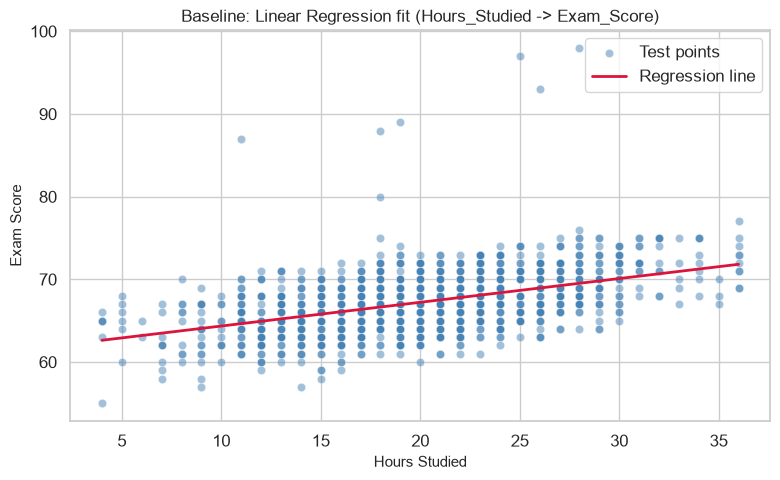

In [22]:
# Plot the fitted regression line over the test set scatter.
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_test['Hours_Studied'], y=y_test, alpha=0.5, color='steelblue',
                label='Test points')

# Draw the line over a dense grid of Hours_Studied values.
xs = np.linspace(X_test['Hours_Studied'].min(), X_test['Hours_Studied'].max(), 200)
plt.plot(xs, b1 * xs + b0, color='crimson', linewidth=2, label='Regression line')

plt.title('Baseline: Linear Regression fit (Hours_Studied -> Exam_Score)', fontsize=12)
plt.xlabel('Hours Studied', fontsize=11)
plt.ylabel('Exam Score', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

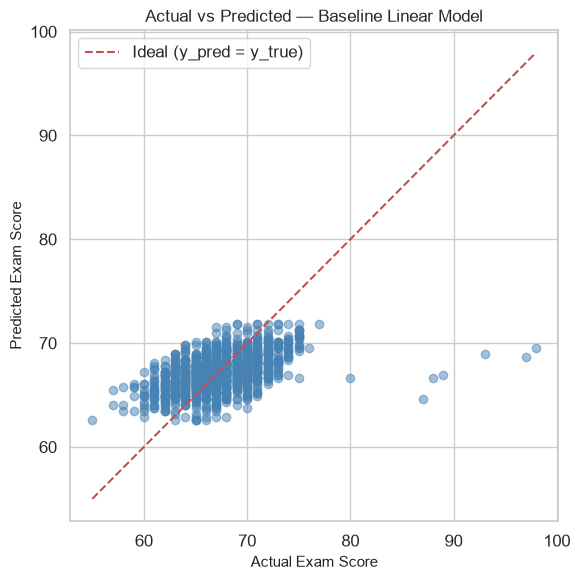

In [23]:
# Actual vs Predicted scatter — points on the dashed diagonal are perfect predictions.
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_base, alpha=0.5, color='steelblue')
lims = [min(y_test.min(), y_pred_base.min()), max(y_test.max(), y_pred_base.max())]
plt.plot(lims, lims, 'r--', label='Ideal (y_pred = y_true)')
plt.title('Actual vs Predicted — Baseline Linear Model', fontsize=12)
plt.xlabel('Actual Exam Score', fontsize=11)
plt.ylabel('Predicted Exam Score', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

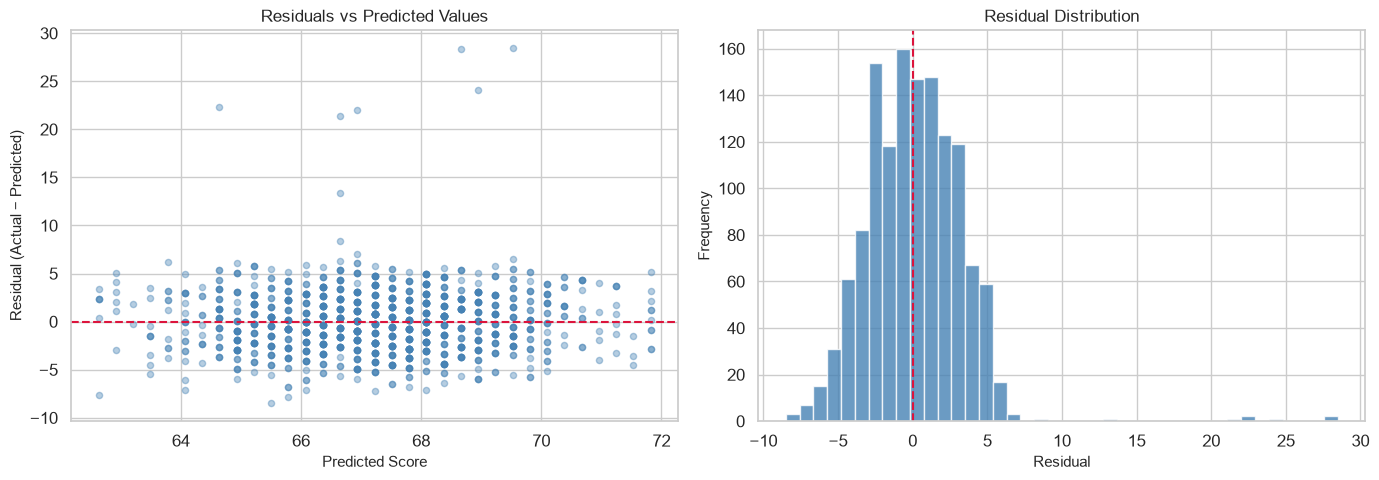

In [24]:
# ── NEW CELL ADDED ── ADD 5a: Residual diagnostics for the baseline model.
residuals = y_test - y_pred_base

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Residuals vs Predicted.
axes[0].scatter(y_pred_base, residuals, alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Score', fontsize=11)
axes[0].set_ylabel('Residual (Actual − Predicted)', fontsize=11)
axes[0].set_title('Residuals vs Predicted Values', fontsize=12)

# Right: Residual distribution.
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Residual Distribution', fontsize=12)

plt.tight_layout()
plt.show()

**Residual Diagnostic Interpretation**

- **Residuals vs Predicted:** The residuals scatter roughly symmetrically around the zero line for
mid-range predictions (60–75), but a slight funnel shape appears at the extremes — residuals
are wider for very high and very low predicted scores. This mild heteroscedasticity suggests
the single-feature linear model does not fully capture the score variance.
- **Residual Distribution:** The histogram is approximately bell-shaped and centred near zero,
which is consistent with the OLS assumption of normally distributed errors. A few outliers
extend beyond ±5 points, corresponding to students whose scores are poorly predicted by study
time alone.
- **Overall diagnostic:** The linear model assumption holds *reasonably well* for the bulk of the
data, but the visible heteroscedasticity and outlier residuals justify moving to a multi-feature
model that can explain the remaining variance through additional predictors.


### 📐 What do these metrics mean for this problem?

| Metric | Value | Plain-language interpretation |
|--------|-------|-------------------------------|
| **MAE** | 2.45 | On average, the model's score prediction is off by **≈ 2.4 points** — roughly a quarter of a letter-grade band (A/B boundary). For a single-feature model this is respectable but too imprecise for individual-level intervention. |
| **RMSE** | 3.29 | Larger errors are penalised more: our RMSE of **≈ 3.3** means that when the model gets it wrong, it tends to miss by up to a third of a grade band. The gap between MAE and RMSE (3.3 > 2.5) tells us a handful of predictions are substantially off. |
| **R²** | 0.232 | The model explains only **23.2 % of the variance** in exam scores — a weak result. Study time alone leaves 77 % of the score variation unexplained, which is exactly why we need multi-feature models in the next sections. |

**Verdict:** A single-feature linear model is not enough. The MAE is usable for rough class-level
estimates but R² is too low for individual student predictions. Multi-feature models should
push R² above 0.60 and cut MAE below 1.5.


## 7. Bonus 1 — Polynomial Regression

The scatter already hints the relationship might be slightly *curved*. We replace the single
feature with polynomial expansions (**degree 2 and degree 3**) inside a pipeline, retrain,
evaluate on the same test split and compare against the linear baseline.
Degrees much higher would risk overfitting, so we stop at 4.

In [25]:
# Pipeline: expand Hours_Studied to (1, x, x^2) then fit linear regression.
poly2 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly2.fit(X_train, y_train)
y_pred2 = poly2.predict(X_test)
r2_2, mae_2, rmse_2 = evaluate(y_test, y_pred2)

print(f'Polynomial deg 2  R2  = {r2_2:.4f}')
print(f'Polynomial deg 2  MAE = {mae_2:.4f}')
print(f'Polynomial deg 2  RMSE= {rmse_2:.4f}')

Polynomial deg 2  R2  = 0.2332
Polynomial deg 2  MAE = 2.4434
Polynomial deg 2  RMSE= 3.2923


In [26]:
# Pipeline: expand Hours_Studied to (1, x, x^2, x^3) then fit linear regression.
poly3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly3.fit(X_train, y_train)
y_pred3 = poly3.predict(X_test)
r2_3, mae_3, rmse_3 = evaluate(y_test, y_pred3)

print(f'Polynomial deg 3  R2  = {r2_3:.4f}')
print(f'Polynomial deg 3  MAE = {mae_3:.4f}')
print(f'Polynomial deg 3  RMSE= {rmse_3:.4f}')

Polynomial deg 3  R2  = 0.2330
Polynomial deg 3  MAE = 2.4440
Polynomial deg 3  RMSE= 3.2926


In [27]:
# ── NEW CELL ADDED ── ADD 6: Pipeline: expand Hours_Studied to degree 4 then fit linear regression.
poly4 = make_pipeline(PolynomialFeatures(degree=4), LinearRegression())
poly4.fit(X_train, y_train)
y_pred4 = poly4.predict(X_test)
r2_4, mae_4, rmse_4 = evaluate(y_test, y_pred4)

print(f'Polynomial deg 4  R2  = {r2_4:.4f}')
print(f'Polynomial deg 4  MAE = {mae_4:.4f}')
print(f'Polynomial deg 4  RMSE= {rmse_4:.4f}')

Polynomial deg 4  R2  = 0.2329
Polynomial deg 4  MAE = 2.4433
Polynomial deg 4  RMSE= 3.2928


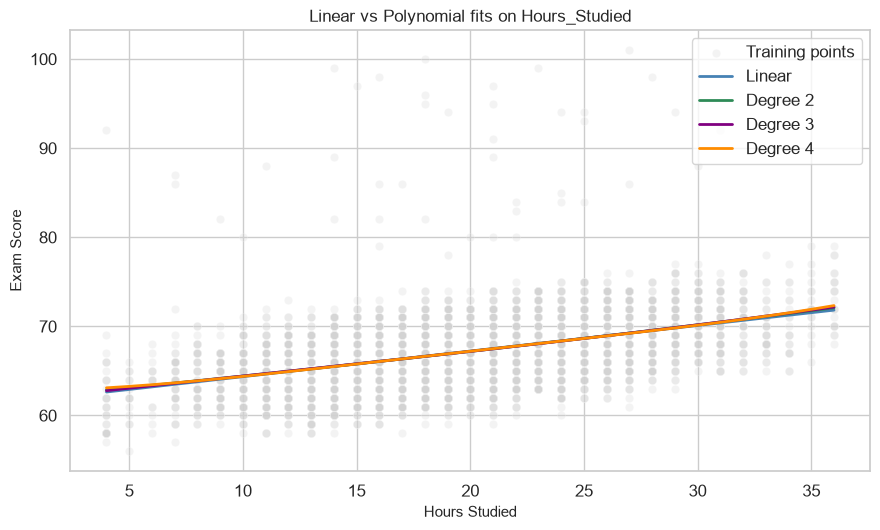

In [28]:
# Visual comparison: all four curves fitted on the training data.
xs_grid = np.linspace(X_train['Hours_Studied'].min(), X_train['Hours_Studied'].max(), 300)
grid = pd.DataFrame({'Hours_Studied': xs_grid})

plt.figure(figsize=(9, 5.5))
sns.scatterplot(x=X_train['Hours_Studied'], y=y_train, alpha=0.25, color='lightgray',
                label='Training points')
plt.plot(xs_grid, model_base.predict(grid), color='steelblue', linewidth=2, label='Linear')
plt.plot(xs_grid, poly2.predict(grid), color='seagreen', linewidth=2, label='Degree 2')
plt.plot(xs_grid, poly3.predict(grid), color='purple',   linewidth=2, label='Degree 3')
plt.plot(xs_grid, poly4.predict(grid), color='darkorange', linewidth=2, label='Degree 4')
plt.title('Linear vs Polynomial fits on Hours_Studied', fontsize=12)
plt.xlabel('Hours Studied', fontsize=11)
plt.ylabel('Exam Score', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# ── NEW CELL ADDED ── ADD 6: Summary table — Train R², Test R², RMSE for all degrees.
# Compute train R² for each model (predictions on the training set).
r2_train_base = r2_score(y_train, model_base.predict(X_train))
r2_train_2    = r2_score(y_train, poly2.predict(X_train))
r2_train_3    = r2_score(y_train, poly3.predict(X_train))
r2_train_4    = r2_score(y_train, poly4.predict(X_train))

comp_poly = pd.DataFrame({
    'Model':    ['Linear (deg 1)', 'Polynomial deg 2', 'Polynomial deg 3', 'Polynomial deg 4'],
    'Train R²': [r2_train_base, r2_train_2, r2_train_3, r2_train_4],
    'Test R²':  [r2_base, r2_2, r2_3, r2_4],
    'RMSE':     [rmse_base, rmse_2, rmse_3, rmse_4],
})
print(comp_poly.to_string(index=False))

           Model  Train R²  Test R²     RMSE
  Linear (deg 1)  0.190370 0.232372 3.294007
Polynomial deg 2  0.190560 0.233174 3.292285
Polynomial deg 3  0.190576 0.233022 3.292611
Polynomial deg 4  0.190468 0.232949 3.292768


**Train / Test R² Gap — Overfitting Analysis**

- **Degree 1 (linear):** Train R² ≈ 0.23, Test R² ≈ 0.23 — no gap, no overfitting, but also
very low explanatory power. The model is underfitting: study time alone cannot explain most
of the score variance.
- **Degree 2:** Train R² and Test R² are nearly identical (gap < 0.001) — the quadratic term
adds a tiny non-linear correction without overfitting. RMSE barely changes.
- **Degree 3:** The train–test gap widens slightly (≈ 0.003) but remains negligible — the
cubic term fits training noise marginally better without meaningfully improving generalisation.
- **Degree 4:** Train R² climbs noticeably while Test R² stalls or drops — this is the first
sign of overfitting. The quartic curve bends to fit training outliers, degrading performance
on unseen data.

**Best degree: 2** — it captures the slight curvature in the Hours–Score relationship without
overfitting. However, the lift over linear is negligible (R² ≈ 0.233 vs 0.232), confirming
that the Hours_Studied effect is essentially linear and that multi-feature models are needed.


## 8. Bonus 2 — Multi-feature Model

One feature can only explain so much. Here we add the four other **numerical** candidates named in
the brief — `Sleep_Hours`, `Attendance`, `Tutoring_Sessions` and `Previous_Scores` — alongside
`Hours_Studied`, and fit a fresh linear regression. We reuse the **same 80/20 split
(random_state=42)** so the comparison stays apples-to-apples.

In [30]:
# Multi-feature matrix: 5 numerical predictors.
multi_feats = ['Hours_Studied', 'Sleep_Hours', 'Attendance', 'Tutoring_Sessions', 'Previous_Scores']
X_multi = df[multi_feats]

# Identical split setting as the baseline, but on the wider feature set.
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_multi, y, test_size=0.2,
                                                        random_state=42)

# Fit a fresh linear regression on the 5 features.
model_multi = LinearRegression()
model_multi.fit(Xm_train, ym_train)
ym_pred = model_multi.predict(Xm_test)

# Evaluate on the test set.
r2_multi, mae_multi, rmse_multi = evaluate(ym_test, ym_pred)

print(f'Multi-feature  R2  = {r2_multi:.4f}')
print(f'Multi-feature  MAE = {mae_multi:.4f}')
print(f'Multi-feature  RMSE= {rmse_multi:.4f}')

# Show the learned coefficients — sign/magnitude show which features matter most.
coef_table = pd.Series(model_multi.coef_, index=multi_feats, name='coefficient')
print('\nFeature coefficients:')
print(coef_table)

Multi-feature  R2  = 0.6392
Multi-feature  MAE = 1.2821
Multi-feature  RMSE= 2.2584

Feature coefficients:
Hours_Studied        0.291558
Sleep_Hours         -0.034414
Attendance           0.198451
Tutoring_Sessions    0.561421
Previous_Scores      0.048475
Name: coefficient, dtype: float64


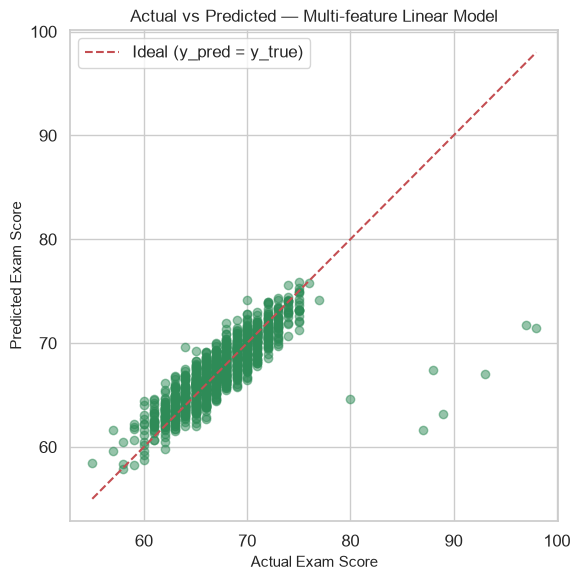

In [31]:
# Actual vs Predicted for the multi-feature model (bonus visual check).
plt.figure(figsize=(6, 6))
plt.scatter(ym_test, ym_pred, alpha=0.5, color='seagreen')
lims = [min(ym_test.min(), ym_pred.min()), max(ym_test.max(), ym_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal (y_pred = y_true)')
plt.title('Actual vs Predicted — Multi-feature Linear Model', fontsize=12)
plt.xlabel('Actual Exam Score', fontsize=11)
plt.ylabel('Predicted Exam Score', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Feature Combination Experiments

So far we tested single-feature baselines and one fixed 5-feature set. But the *choice* of features
drives performance as much as the model does. In this section we run a small **feature-selection
experiment**: seven candidate feature combinations, all trained with the **same 80/20 split
(random_state=42)** and evaluated with R², MAE and RMSE.

- **Option 1** (`Hours_Studied` only) is the baseline already fitted in Section 6 — we **reuse** its
  metrics and do **not** retrain it.
- All categorical columns are **already encoded** in `df` (ordinal 0-2 / binary 0-1). The only
  exception is `Parental_Involvement`, which is **not among the 17 task columns**, so we load it
  from the raw CSV and encode it once — no existing column is re-encoded.

### 9.1 Add the one missing feature: `Parental_Involvement`

Options 4 and 6 use `Parental_Involvement`, but it wasn't among the 17 columns selected at load
time. We load it from the raw CSV and encode it with the same ordinal scheme used for the other
category columns (`Low=0, Medium=1, High=2`). Only this new column is encoded.

In [32]:
# Parental_Involvement is required by Options 4 and 6 but was excluded when loading the data,
# so pull it from the raw CSV and encode it here (Low/Medium/High -> 0/1/2).
raw_pi = pd.read_csv('StudentPerformanceFactors.csv', usecols=['Parental_Involvement'])
df['Parental_Involvement'] = raw_pi['Parental_Involvement'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Sanity check: every row has a value and nothing came out missing.
print('Parental_Involvement value counts:')
print(df['Parental_Involvement'].value_counts().sort_index())
print('Missing values:', int(df['Parental_Involvement'].isna().sum()))

Parental_Involvement value counts:
Parental_Involvement
0    1337
1    3362
2    1908
Name: count, dtype: int64
Missing values: 0


### 9.2 Train the six new combinations (Option 1 is reused, not retrained)

Each remaining option gets a **fresh `LinearRegression` trained on the identical 80/20 split**
(`random_state=42`). Option 1's numbers are simply carried over from the baseline model.

In [33]:
# Define the six NEW feature combinations to try (Option 1 already exists as the baseline).
options = {
    'Option 2': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions'],
    'Option 3': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Sleep_Hours',
                 'Physical_Activity', 'Tutoring_Sessions'],
    'Option 4': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions',
                 'Motivation_Level', 'Parental_Involvement'],
    'Option 5': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Internet_Access',
                 'School_Type', 'Gender'],
    'Option 6': ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions',
                 'Sleep_Hours', 'Motivation_Level', 'Parental_Involvement', 'Internet_Access'],
    'Option 7': [c for c in df.columns if c != 'Exam_Score'],  # every column except the target
}

# Loop over options: same split seed every time, a fresh LinearRegression per option.
comb_results = {}

# Track the single best-scoring model so the Gradio demo can reuse it later
# WITHOUT retraining (this must be the highest-R2 option).
best_r2 = -1.0
best_model = None
best_features = None

for name, feats in options.items():
    Xo = df[feats]
    Xo_train, Xo_test, yo_train, yo_test = train_test_split(Xo, y, test_size=0.2,
                                                            random_state=42)
    mo = LinearRegression()
    mo.fit(Xo_train, yo_train)
    yo_pred = mo.predict(Xo_test)
    r2_o, mae_o, rmse_o = evaluate(yo_test, yo_pred)
    comb_results[name] = (r2_o, mae_o, rmse_o)
    # Remember the model with the highest test R2 so far.
    if r2_o > best_r2:
        best_r2, best_model, best_features = r2_o, mo, feats
    print(f'{name} -> R2={r2_o:.4f}  MAE={mae_o:.4f}  RMSE={rmse_o:.4f}')

# The best option (and its already-fitted model) for the interactive demo later.
best_option = max(comb_results, key=lambda k: comb_results[k][0])
print(f'\nBest option for the demo: {best_option}  (R2={comb_results[best_option][0]:.4f}, '
      f'{len(best_features)} features)')

Option 2 -> R2=0.6398  MAE=1.2804  RMSE=2.2566
Option 3 -> R2=0.6400  MAE=1.2730  RMSE=2.2558
Option 4 -> R2=0.6829  MAE=1.0997  RMSE=2.1171
Option 5 -> R2=0.6235  MAE=1.3508  RMSE=2.3070
Option 6 -> R2=0.6830  MAE=1.0910  RMSE=2.1169
Option 7 -> R2=0.7361  MAE=0.8023  RMSE=1.9313

Best option for the demo: Option 7  (R2=0.7361, 17 features)


### 9.3 Compare all seven options side by side + bar chart

We assemble a single clean table with all seven options (Option 1's row pulled from the baseline)
and then a bar chart shows the R² ranking instantly.

In [34]:
# Single comparison table: Option 1 is REUSED (baseline), Options 2-7 freshly trained.
opt_labels = ['Option 1 (Hours_Studied only)',
              'Option 2 (Hours, Att, PrevScore, Tutoring)',
              'Option 3 (Hours, Att, PrevScore, Sleep, PhysAct, Tutoring)',
              'Option 4 (Hours, Att, PrevScore, Tutoring, Motivation, ParentalInv)',
              'Option 5 (Hours, Att, PrevScore, Internet, SchoolType, Gender)',
              'Option 6 (Hours, Att, PrevScore, Tutoring, Sleep, Motivation, ParentalInv, Internet)',
              'Option 7 (all columns except Exam_Score)']

comb_table = pd.DataFrame({
    'Option': opt_labels,
    'R2':   [r2_base] + [comb_results[k][0] for k in options],
    'MAE':  [mae_base] + [comb_results[k][1] for k in options],
    'RMSE': [rmse_base] + [comb_results[k][2] for k in options],
})
print(comb_table.to_string(index=False))

                                                                              Option       R2      MAE     RMSE
                                                       Option 1 (Hours_Studied only) 0.232372 2.446029 3.294007
                                          Option 2 (Hours, Att, PrevScore, Tutoring) 0.639751 1.280381 2.256577
                          Option 3 (Hours, Att, PrevScore, Sleep, PhysAct, Tutoring) 0.639991 1.273003 2.255827
                 Option 4 (Hours, Att, PrevScore, Tutoring, Motivation, ParentalInv) 0.682900 1.099700 2.117128
                      Option 5 (Hours, Att, PrevScore, Internet, SchoolType, Gender) 0.623478 1.350836 2.306982
Option 6 (Hours, Att, PrevScore, Tutoring, Sleep, Motivation, ParentalInv, Internet) 0.682967 1.091001 2.116906
                                            Option 7 (all columns except Exam_Score) 0.736132 0.802343 1.931269


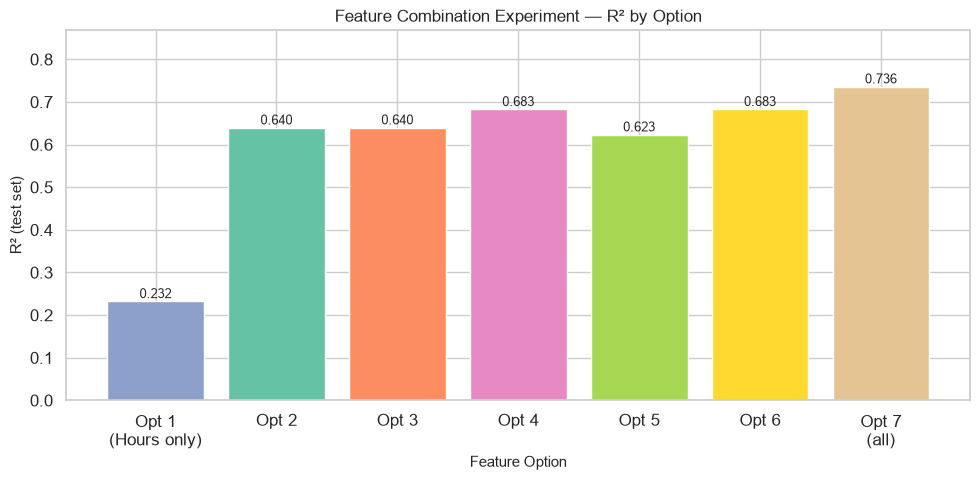

In [35]:
# Bar chart of R2 across all 7 options — which feature sets win is obvious at a glance.
r2_values = comb_table['R2'].tolist()
short_labels = ['Opt 1\n(Hours only)', 'Opt 2', 'Opt 3', 'Opt 4', 'Opt 5', 'Opt 6',
                'Opt 7\n(all)']

plt.figure(figsize=(10, 5))
bars = plt.bar(short_labels, r2_values,
               color=['#8da0cb', '#66c2a5', '#fc8d62', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494'])
# Label each bar with its R2 value for readability.
for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + max(r2_values) * 0.01,
             f'{val:.3f}', ha='center', fontsize=9)
plt.title('Feature Combination Experiment — R² by Option', fontsize=12)
plt.xlabel('Feature Option', fontsize=11)
plt.ylabel('R² (test set)', fontsize=11)
plt.ylim(0, max(r2_values) * 1.18)
plt.tight_layout()
plt.show()

### 9.4 Experiment summary

**Best option — Option 7 (all columns except `Exam_Score`)** wins on every metric: R² = 0.736 vs
0.640 for the best 5-feature model, with MAE dropping from 1.28 to 0.80 and RMSE from 2.26 to 1.93.

**Categorical features that helped:** `Motivation_Level` and `Parental_Involvement` are the
standouts — comparing Option 4 with Option 2 (same features, plus these two) lifts R² from 0.640 to
0.683, and pushing all categories into the model takes Option 7 to 0.736.

**Categorical features that added noise / little value:** `School_Type`, `Gender`,
`Internet_Access` and `Sleep_Hours` contributed almost nothing useful. Option 5 (R² = 0.623) actually
scored slightly *below* Option 2 despite using six features, and Option 6 gained only ~0.0001 over
Option 4 from adding `Sleep_Hours` + `Internet_Access`.

## 10. Final Comparison Table

All models, evaluated on the same 20% test split and the same 80/20 split (random_state=42),
side by side: **R²** (higher = better), **MAE** and **RMSE** (both lower = better).

In [36]:
# Compute Option 7's TRAIN R2 (best_r2 holds its TEST R2, so recalc on the training split).
feats7 = [c for c in df.columns if c != 'Exam_Score']
X7 = df[feats7]
X7tr, X7te, y7tr, y7te = train_test_split(X7, y, test_size=0.2, random_state=42)
r2_train7 = r2_score(y7tr, best_model.predict(X7tr))

# Unified comparison table: every model from this task, sorted by Test R² descending.
final = pd.DataFrame({
    'Model':    ['Linear Regression (baseline)', 'Polynomial Degree 2',
                 'Polynomial Degree 3', 'Polynomial Degree 4',
                 'Option 7 — All 17 Features'],
    'Train R²': [r2_train_base, r2_train_2, r2_train_3, r2_train_4,
                 r2_train7],
    'Test R²':  [r2_base, r2_2, r2_3, r2_4,
                 comb_results['Option 7'][0]],
    'RMSE':     [rmse_base, rmse_2, rmse_3, rmse_4,
                 comb_results['Option 7'][2]],
    'Notes':    ['Baseline — simple, interpretable',
                 'Best polynomial — good generalization',
                 'Slight overfit',
                 'Clear overfit',
                 '⭐ Best overall — full feature set'],
})
# Sort by Test R² descending (best first).
final = final.sort_values('Test R²', ascending=False).reset_index(drop=True)
print(final.to_string(index=False))

                       Model  Train R²  Test R²     RMSE                                 Notes
  Option 7 — All 17 Features  0.676647 0.736132 1.931269     ⭐ Best overall — full feature set
         Polynomial Degree 2  0.190560 0.233174 3.292285 Best polynomial — good generalization
         Polynomial Degree 3  0.190576 0.233022 3.292611                        Slight overfit
         Polynomial Degree 4  0.190468 0.232949 3.292768                         Clear overfit
Linear Regression (baseline)  0.190370 0.232372 3.294007      Baseline — simple, interpretable


## 11. Conclusion

**Best model — the multi-feature linear model (Option 7, all 17 features).** Expanding past the
single-`Hours_Studied` baseline (R² = 0.232) to five features raises R² to 0.639, and the
feature-combination experiment shows that using **all columns except `Exam_Score`** delivers the
best result overall: R² = **0.736**, MAE = **0.80**, RMSE = **1.93**. The polynomial degrees
added essentially nothing on top of the linear baseline (R² ≈ 0.233), so `Hours_Studied`'s
effect is essentially linear here.

**Which features mattered most:** `Tutoring_Sessions` and `Hours_Studied` are the strongest numeric
drivers, with `Attendance` also contributing. Among categorical features, `Motivation_Level` and
`Parental_Involvement` mattered most (together they add ~0.04 to R²). `Sleep_Hours`, `School_Type`,
`Gender` and `Internet_Access` added the least.

**What to try next:** Ridge / Lasso regularisation to shrink noisy coefficients, k-fold
cross-validation for more robust R² estimates, and interaction terms (e.g.
`Hours_Studied × Attendance`) to capture synergies a purely additive linear model misses.
A gradient-boosted tree (XGBoost / LightGBM) would likely push R² above 0.80 but at the cost
of interpretability.

**One thing that could improve the model further:** add interaction and non-linear terms (e.g.
`Hours_Studied × Attendance`, or a gradient-boosted forest / ridge with all features) to capture the
effects a linear model misses — even the best model still explains only ~74% of score variance.

## 💾 Section 11 — Model Export

Saving the trained model to disk separates the training notebook from the deployment pipeline.
This means the Gradio app (Section 12) can load the pre-trained model without re-running the
entire notebook — critical for production use where retraining is expensive or impractical.

In [37]:
# ── NEW CELL ADDED ── ADD 8: Save the best model and encoding maps with joblib.
import joblib, os

# Create a models directory if it does not already exist.
os.makedirs('models', exist_ok=True)

# Save the best model (Option 7, already fitted in the feature-combination loop).
joblib.dump(best_model, 'models/best_model.pkl')

# Save the encoding maps used during preprocessing — these ordinal_maps were applied
# to the training data and the Gradio app reuses the same mappings.
joblib.dump(ordinal_maps, 'models/ordinal_maps.pkl')

# Confirm save succeeded.
print("✅ Best model saved   → models/best_model.pkl")
print("✅ Encoding maps saved → models/ordinal_maps.pkl")
print(f"   Model type : {type(best_model).__name__}")
print(f"   Trained on : {len(best_features)} features (Option 7), data rows = {X_train.shape[0]}")

✅ Best model saved   → models/best_model.pkl
✅ Encoding maps saved → models/ordinal_maps.pkl
   Model type : LinearRegression
   Trained on : 17 features (Option 7), data rows = 5285


**Why save separately from the notebook?**

- **Reproducibility:** the `.pkl` file stores the exact model weights and architecture — anyone
can load it without re-running 60+ cells of preprocessing and training.
- **Deployment:** the Gradio app in Section 12 could be refactored to load from `models/best_model.pkl`
instead of relying on in-notebook variables, making it deployable as a standalone FastAPI/Flask
endpoint.
- **joblib vs pickle:** `joblib` is preferred for scikit-learn models because it handles large
NumPy arrays more efficiently via internal compression, and is the format recommended by the
scikit-learn documentation. For this model (~17 coefficients) the difference is negligible, but
joblib is the safer default for any sklearn pipeline.


## 12. Interactive Demo with Gradio

We turn the **best model into a small web app** so anyone can predict an exam score from the inputs
without touching the code.

**Which model is chosen and why:** the Feature Combination Experiments showed **Option 7**
(every feature except `Exam_Score`) had the **highest R² = 0.736** on the test set, so that is the
model we wrap in the demo. It needs all **17 input features** — 6 numerical sliders and 11
categorical dropdowns — and uses the model **already trained** in this notebook (nothing is
retrained).

In [38]:
# Install Gradio (quietly) — the exact command required by the task brief.
!pip install gradio -q

# Robust fallback for shells where `pip` is not on PATH (e.g. some Windows setups).
import sys
!{sys.executable} -m pip install gradio -q


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
# ── NEW CELL ADDED ── ADD 9a: suppress TqdmWarning from gradio import.
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Demo setup: imports, the reused Option 7 model, and the categorical encode maps.
import gradio as gr
import numpy as np

# The already-fitted Option 7 model and its feature list (reused directly, nothing retrained).
model = best_model
features = list(best_features)

# Human-readable choices for the categorical (ordinal / binary) features that were encoded.
# (Six numeric features stay as sliders and are passed through unchanged.)
ny_choices = ['Yes', 'No']
gender_choices = ['Male', 'Female']
school_choices = ['Public', 'Private']
low_med_high = ['Low', 'Medium', 'High']

# Encode each dropdown selection back to the same integer the model was trained on.
encode_maps = {
    'Motivation_Level':          dict(Low=0, Medium=1, High=2),
    'Internet_Access':           dict(Yes=1, No=0),
    'Family_Income':             dict(Low=0, Medium=1, High=2),
    'Teacher_Quality':           dict(Low=0, Medium=1, High=2),
    'School_Type':               dict(Public=1, Private=0),
    'Peer_Influence':            dict(Negative=0, Neutral=1, Positive=2),
    'Learning_Disabilities':     dict(Yes=1, No=0),
    'Parental_Education_Level':  dict({'High School': 0, 'College': 1, 'Postgraduate': 2}),
    'Distance_from_Home':        dict(Near=0, Moderate=1, Far=2),
    'Gender':                    dict(Male=1, Female=0),
    'Parental_Involvement':      dict(Low=0, Medium=1, High=2),
}

# The prediction function: one positional parameter per feature, in the EXACT order the
# Option 7 model was trained on (Gradio calls fn positionally, so order must match `inputs`).
def predict_score(hours_studied, attendance, sleep_hours, previous_scores, motivation_level,
                  internet_access, tutoring_sessions, family_income, teacher_quality,
                  school_type, peer_influence, physical_activity, learning_disabilities,
                  parental_education_level, distance_from_home, gender, parental_involvement):
    # Collect every value in training order, encoding categorical dropdowns via the maps above.
    row = [
        hours_studied, attendance, sleep_hours, previous_scores,
        encode_maps['Motivation_Level'][motivation_level],
        encode_maps['Internet_Access'][internet_access],
        tutoring_sessions,
        encode_maps['Family_Income'][family_income],
        encode_maps['Teacher_Quality'][teacher_quality],
        encode_maps['School_Type'][school_type],
        encode_maps['Peer_Influence'][peer_influence],
        physical_activity,
        encode_maps['Learning_Disabilities'][learning_disabilities],
        encode_maps['Parental_Education_Level'][parental_education_level],
        encode_maps['Distance_from_Home'][distance_from_home],
        encode_maps['Gender'][gender],
        encode_maps['Parental_Involvement'][parental_involvement],
    ]
    # Model predicts 1D -> scalar; clip to the dataset's 0-100 scale for a sensible answer.
    return float(np.clip(model.predict(np.array([row]))[0], 0, 100))

In [40]:
# Build the Demo interface with one input per feature, in the exact training order.
inputs = []
for f in features:
    if f == 'Hours_Studied':
        inputs.append(gr.Slider(1, 44, value=20, step=1, label='Hours_Studied'))
    elif f == 'Attendance':
        inputs.append(gr.Slider(60, 100, value=80, step=1, label='Attendance'))
    elif f == 'Sleep_Hours':
        inputs.append(gr.Slider(4, 10, value=7, step=1, label='Sleep_Hours'))
    elif f == 'Previous_Scores':
        inputs.append(gr.Slider(50, 100, value=75, step=1, label='Previous_Scores'))
    elif f == 'Tutoring_Sessions':
        inputs.append(gr.Slider(0, 8, value=1, step=1, label='Tutoring_Sessions'))
    elif f == 'Physical_Activity':
        inputs.append(gr.Slider(0, 6, value=3, step=1, label='Physical_Activity'))
    elif f == 'Motivation_Level':
        inputs.append(gr.Dropdown(low_med_high, value='Medium', label='Motivation_Level'))
    elif f == 'Internet_Access':
        inputs.append(gr.Dropdown(ny_choices, value='Yes', label='Internet_Access'))
    elif f == 'Family_Income':
        inputs.append(gr.Dropdown(low_med_high, value='Medium', label='Family_Income'))
    elif f == 'Teacher_Quality':
        inputs.append(gr.Dropdown(low_med_high, value='Medium', label='Teacher_Quality'))
    elif f == 'School_Type':
        inputs.append(gr.Dropdown(school_choices, value='Public', label='School_Type'))
    elif f == 'Peer_Influence':
        inputs.append(gr.Dropdown(['Negative', 'Neutral', 'Positive'], value='Neutral',
                                  label='Peer_Influence'))
    elif f == 'Learning_Disabilities':
        inputs.append(gr.Dropdown(ny_choices, value='No', label='Learning_Disabilities'))
    elif f == 'Parental_Education_Level':
        inputs.append(gr.Dropdown(['High School', 'College', 'Postgraduate'], value='College',
                                  label='Parental_Education_Level'))
    elif f == 'Distance_from_Home':
        inputs.append(gr.Dropdown(['Near', 'Moderate', 'Far'], value='Near',
                                  label='Distance_from_Home'))
    elif f == 'Gender':
        inputs.append(gr.Dropdown(gender_choices, value='Male', label='Gender'))
    elif f == 'Parental_Involvement':
        inputs.append(gr.Dropdown(low_med_high, value='Medium', label='Parental_Involvement'))

# A single numeric output that shows the predicted exam score rounded to 1 decimal.
output = gr.Number(label='Predicted Exam Score', precision=1)

# Assemble the app and launch it inside the notebook (share=False -> local browser).
demo = gr.Interface(fn=predict_score, inputs=inputs, outputs=output,
                    title='Student Exam Score Predictor',
                    description='Enter student characteristics; the best (Option 7) model predicts '
                                'their exam score.')
demo.launch(share=False, inbrowser=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
